In [1]:
import numpy as np
import json
import torch
from pathlib import Path

from src.models.TransformerBottleneck_model import TransformerBottleneck_model
from src.models.model_utilizer import load_net
from src.dataloaders.ZerosPolesDataset import ConversionTransforms
from usecases.utils.test_nb_functions import zeros_poles_freq_to_positions, plot_responses

In [2]:
if torch.cuda.is_available():
    print("CUDA is available!")
    print(f"Number of GPUs: {torch.cuda.device_count()}")
    print(f"Current GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"CUDA Version used by PyTorch: {torch.version.cuda}")
    v = torch.backends.cudnn.version()
    print(f"cuDNN: {v//10000}.{(v%1000)//100}.{v%100}")
else:
    print("CUDA is not available. PyTorch is using CPU.")

CUDA is available!
Number of GPUs: 1
Current GPU Name: NVIDIA GeForce RTX 3060
CUDA Version used by PyTorch: 12.6
cuDNN: 9.5.1


Выбор модели.

In [3]:
model_name = 'TransformerBottleneck-model_postactivation'
log_name = 'TransformerBottleneck-model_postactivation'

Пути к каталогам.

In [4]:
config_dir = Path("./src/config/")

config_path = config_dir / "config.json"
assert config_path.exists(), f"Config not found: {config_path}"
with open(config_path, "r") as f:
    general_config = json.load(f)

checkpoints_dir = Path(general_config['checkpoints_dir'])
logs_dir = Path(general_config['logs_dir'])

model_log_path = logs_dir / f"{log_name}.json"
assert model_log_path.exists(), f"Config not found: {model_log_path}"
with open(model_log_path, "r") as f:
    model_log = json.load(f)

train_log = model_log["train_log"]
best_epoch = model_log["summary"]["best_epoch"]

Импорт модели.

In [5]:
device = torch.device(general_config["device"].lower() if torch.cuda.is_available() else 'cpu')

model = TransformerBottleneck_model(
    in_channels = 4,
    out_channels = 4,
    features = model_log["metadata"]["model"]["feature_list"]
    )

model = model.to(device)
model, _, _, _ = load_net(
    net = model,
    checkpoints_file = checkpoints_dir / f"best_{model_name}.pth",
    device = device
    )

model.eval()

transform = ConversionTransforms(
    num_iter=2,
    return_input=False
    )

Restoring checkpoint:  checkpoints\best_TransformerBottleneck-model_postactivation.pth


## Чтение данных из csv-файлов

Директория с файлами и имена.

In [6]:
sample_dir = Path("usecases/test_samples/extra")
sample_file_name_list = ["LPF"]

Координаты нулей/полюсов.

In [7]:
fs = 100000
k = 12566.3706143592 / fs
fp = 2*k*fs /(2-k) / (2*np.pi)
fz = 1.3 * fs / np.pi

print('fp:', np.round(fp, 4))
print('fz:', np.round(fz, 4))

fp: 2134.0888
fz: 41380.2852


In [8]:
Uout = 48
Pout_nom = 120
Uin = 24
R = Pout_nom/Uout * 2 # * np.array([1, 2])
L = 136e-6
C = 4 * 100e-6
ESR = 87e-3 / 4

Le = (Uout / Uin)**2 * L

w_c = 1 / (R*C)
w_ESR = 1 / (ESR*C)
w_RHP = R / Le

fmin = 10
fmax = 50e3
N = 512
freq = np.logspace(np.log10(fmin),np.log10(fmax), N)

s = 1j * freq * 2 * np.pi
gain_complex = Uin / Uout * R/2 * (1 - s/w_RHP)*(1 + s/w_ESR) / (1 + s/(2*w_c))

data = np.array([
    freq,
    20*np.log10(np.abs(gain_complex)),
    180 / np.pi * np.unwrap(np.angle(gain_complex))
])
data_list = [data]

In [9]:
positions_flag = False
interp_flag = False

if positions_flag:
    zeros_poles_positions_path = sample_dir/ "test_masks.json"
    assert zeros_poles_positions_path.exists(), f"Config not found: {zeros_poles_positions_path}"
    with open(zeros_poles_positions_path, "r") as f:
        zeros_poles_positions_full = json.load(f)
    zeros_poles_positions_list = []
    for sample_file_name in sample_file_name_list:
        zeros_poles_positions_list.append(zeros_poles_positions_full[sample_file_name])

    for zeros_poles_positions in zeros_poles_positions_list:
        zeros_poles_positions.pop('zero_poles')

    zeros_poles_list = zeros_poles_positions_list.copy()
else:
    zeros_poles_freq_list = [
        {
        "left_poles": [2*w_c/(2*np.pi)],
        "right_poles": [],
        "left_zeros": [w_ESR/(2*np.pi)],
        "right_zeros": [w_RHP/(2*np.pi)]
        }
    ]
    zeros_poles_list = zeros_poles_freq_list.copy()

In [10]:
'''
ext = '.csv'

if sample_file_name_list is None:
    sample_file_name_list = [f.stem for f in sample_dir.glob('*'+ext)]

data_list = []
for sample_file_name in sample_file_name_list:
        data_list.append(np.loadtxt(sample_dir / (sample_file_name + ext), delimiter=',', skiprows=1).T)
'''

"\next = '.csv'\n\nif sample_file_name_list is None:\n    sample_file_name_list = [f.stem for f in sample_dir.glob('*'+ext)]\n\ndata_list = []\nfor sample_file_name in sample_file_name_list:\n        data_list.append(np.loadtxt(sample_dir / (sample_file_name + ext), delimiter=',', skiprows=1).T)\n"

Интерполяция данных (по требованию).

In [11]:
if interp_flag:
    data_list_interp = []
    for data in data_list:
        freq = data[0,:]
        mag_ph = np.array([data[1,:], data[2,:]])

        freq_log = np.logspace(np.log10(freq.min()), np.log10(freq.max()), num=512)
        mag_ph_interp = np.array([np.interp(freq_log, freq, y) for y in mag_ph])
        data_interp = np.vstack((freq_log, mag_ph_interp))
        data_list_interp.append(data_interp)
    data_list = data_list_interp.copy()

Инференс.

In [12]:
mask_threshold = model_log["metadata"]["model"]["mask_threshold"]

predictions_list = []
for data in data_list:
        inputs = torch.from_numpy(np.ascontiguousarray(transform(data), dtype=np.float32))
        with torch.no_grad():
                logits = model(inputs.unsqueeze(0).to(device))
                predictions_list.append((torch.sigmoid(logits.squeeze(0)) > mask_threshold).float().detach().cpu().numpy())

## Визуализация

In [13]:
with open('usecases/plot_config.json', 'r', encoding='utf-8') as f:
    PLOT_CONFIG = json.load(f)

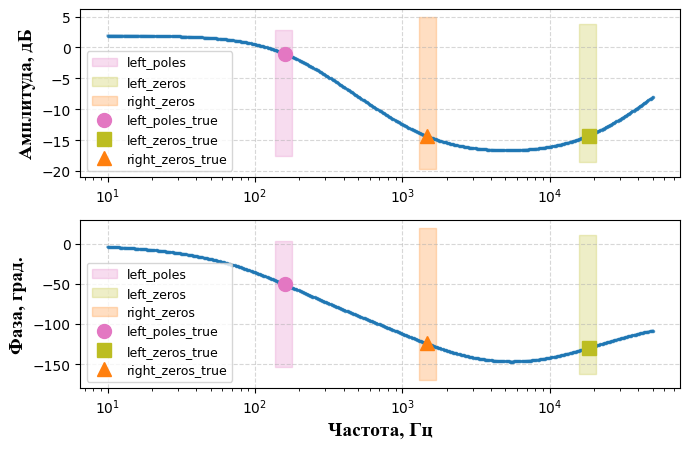

In [14]:
for data, zeros_poles, predictions, sample_file_name in zip(
    data_list,
    zeros_poles_list,
    predictions_list,
    sample_file_name_list
    ):
    if not positions_flag:
        zeros_poles_positions = zeros_poles_freq_to_positions(
            zeros_poles_freq_dict=zeros_poles,
            freq=data[0,:]
            )
    else:
        zeros_poles_positions = zeros_poles.copy()
    
    plot_responses(
        plot_config=PLOT_CONFIG,
        data=data,
        #title=sample_file_name,
        regions=predictions,
        zeros_poles_positions=zeros_poles_positions,
        save_path='usecases/LPF_0.pdf'
        )

# Дополнительный тест

In [15]:
wz = 2*np.pi*fz
wp = 2*np.pi*fp

s = 1j * freq * 2 * np.pi
gain_complex = (1 + s/wz)/(1 + s/wp)
mag_db = 20*np.log10(np.abs(gain_complex))
ph_deg = 180 / np.pi * np.unwrap(np.angle(gain_complex))

'''
from matplotlib import pyplot as plt

plt.plot(freq, y_stack[0])
plt.xscale('log')
plt.plot(freq_log, y_new[0], '--')
plt.plot(freq_log, mag_db)
plt.show()

plt.plot(freq, y_stack[1])
plt.xscale('log')
plt.plot(freq_log, y_new[1], '--')
plt.plot(freq_log, ph_deg)
plt.show()
'''

"\nfrom matplotlib import pyplot as plt\n\nplt.plot(freq, y_stack[0])\nplt.xscale('log')\nplt.plot(freq_log, y_new[0], '--')\nplt.plot(freq_log, mag_db)\nplt.show()\n\nplt.plot(freq, y_stack[1])\nplt.xscale('log')\nplt.plot(freq_log, y_new[1], '--')\nplt.plot(freq_log, ph_deg)\nplt.show()\n"